Шаг 1: Загрузка Данных

In [103]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb

max_words = 10000 
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_words)

print(f'Количество обучающих примеров: {len(x_train)}')
print(f'Количество тестовых примеров: {len(x_test)}')
print(f'Пример отзыва (первые 10 слов): {x_train[0][:10]}')
print(f'Метка отзыва: {y_train[0]}')

Количество обучающих примеров: 25000
Количество тестовых примеров: 25000
Пример отзыва (первые 10 слов): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]
Метка отзыва: 1


In [116]:
import matplotlib.pyplot as plt

def plot_training_history_and_evaluate(model, history, x_test, y_test):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label='Точность на обучающей выборке')
    plt.plot(history.history['val_accuracy'], label='Точность на проверочной выборке')
    plt.xlabel('Эпоха обучения')
    plt.ylabel('Точность')
    plt.title('Точность обучения модели')
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Потери на обучающей выборке')
    plt.plot(history.history['val_loss'], label='Потери на проверочной выборке')
    plt.xlabel('Эпоха обучения')
    plt.ylabel('Потери')
    plt.title('Потери обучения модели')
    plt.legend()
    plt.show()

    test_loss, test_acc = model.evaluate(x_test, y_test)
    print(f'\nТочность модели на тестовых данных: {test_acc:.4f}')

Шаг 2: Предобработка Данных

In [104]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_review_len = 500

x_train_padded = pad_sequences(x_train, maxlen=max_review_len, padding='post')
x_test_padded = pad_sequences(x_test, maxlen=max_review_len, padding='post')

print(f'Форма обучающих данных: {x_train_padded.shape}')
print(f'Форма тестовых данных: {x_test_padded.shape}')

Форма обучающих данных: (25000, 500)
Форма тестовых данных: (25000, 500)


Шаг 3: Построение Базовой Модели с использованием Embedding и Dense Слоев

In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

embedding_dim = 32

model_dense = Sequential([
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_dense.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

history_dense = model_dense.fit(
    x_train_padded, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5056 - loss: 222.6127 - val_accuracy: 0.5004 - val_loss: 63.3847
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5155 - loss: 41.1672 - val_accuracy: 0.4930 - val_loss: 18.1738
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5230 - loss: 11.7016 - val_accuracy: 0.4962 - val_loss: 6.6904
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5155 - loss: 4.3889 - val_accuracy: 0.4962 - val_loss: 3.8742
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5145 - loss: 2.5390 - val_accuracy: 0.4950 - val_loss: 2.7871
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5163 - loss: 1.8463 - val_accuracy: 0.4932 - val_loss: 2.2786
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5214 - loss: 1.3527 - val_accuracy: 0.4936 - val_loss: 1.9795
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5228 - loss: 1.2341 - val_accuracy: 0.4970 - val

Шаг 4: Компиляция и Обучение Базовой Модели

Шаг 5: Визуализация Результатов Обучения Базовой Модели

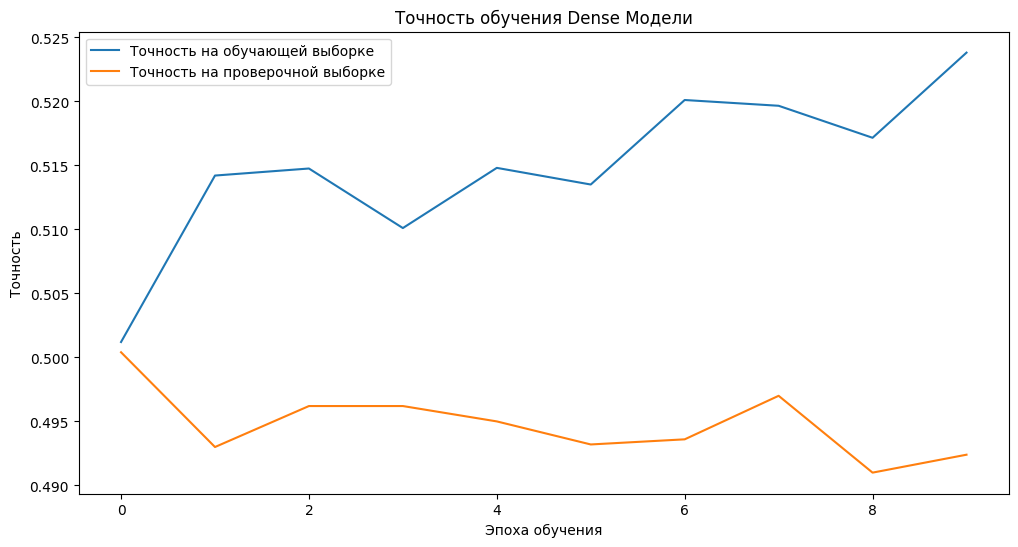

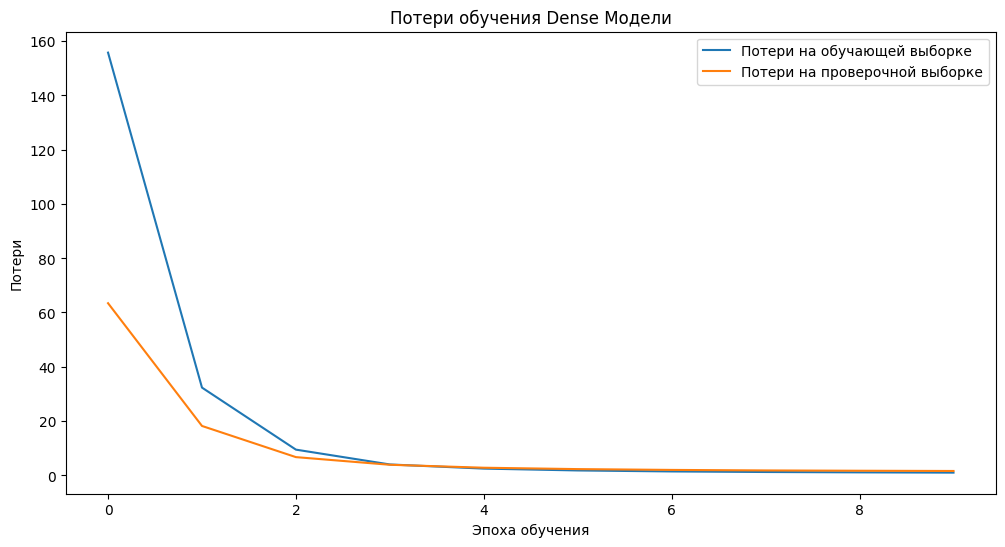

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history_dense.history['accuracy'], label='Точность на обучающей выборке')
plt.plot(history_dense.history['val_accuracy'], label='Точность на проверочной выборке')
plt.xlabel('Эпоха обучения')
plt.ylabel('Точность')
plt.title('Точность обучения Dense Модели')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history_dense.history['loss'], label='Потери на обучающей выборке')
plt.plot(history_dense.history['val_loss'], label='Потери на проверочной выборке')
plt.xlabel('Эпоха обучения')
plt.ylabel('Потери')
plt.title('Потери обучения Dense Модели')
plt.legend()
plt.show()

Шаг 6: Оценка Базовой Модели на Тестовых Данных

In [107]:
test_loss_dense, test_acc_dense = model_dense.evaluate(x_test_padded, y_test)
print(f'\nТочность Dense модели на тестовых данных: {test_acc_dense:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - accuracy: 0.4894 - loss: 1.4760

Точность Dense модели на тестовых данных: 0.4951


In [ ]:
plot_training_history_and_evaluate(model_dense, history_dense, x_test_padded, y_test)

Шаг 7: Построение Модели с использованием Embedding и SimpleRNN Слоев

In [108]:
from tensorflow.keras.layers import SimpleRNN

embedding_dim = 128
model_rnn = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_review_len),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_rnn = model_rnn.fit(
    x_train_padded, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 709ms/step - accuracy: 0.5001 - loss: 0.6936 - val_accuracy: 0.5040 - val_loss: 0.6935
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 677ms/step - accuracy: 0.5175 - loss: 0.6874 - val_accuracy: 0.5002 - val_loss: 0.6961
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 703ms/step - accuracy: 0.5320 - loss: 0.6781 - val_accuracy: 0.4980 - val_loss: 0.7015
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 706ms/step - accuracy: 0.5409 - loss: 0.6512 - val_accuracy: 0.4976 - val_loss: 0.7810
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 705ms/step - accuracy: 0.5376 - loss: 0.6679 - val_accuracy: 0.4936 - val_loss: 0.7080
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 744ms/step - accuracy: 0.5389 - loss: 0.6592 - val_accuracy: 0.5096 - val_loss: 0.7155
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 688ms/step - accuracy: 0.5469 - loss: 0.6359 - val_accuracy: 0.5084 - val_loss: 0.7171
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 687ms/step - accuracy: 0.5457 - loss: 0.6359 - val_accu

Шаг 8: Компиляция и Обучение RNN-Модели

Шаг 9: Визуализация Результатов Обучения RNN-Модели

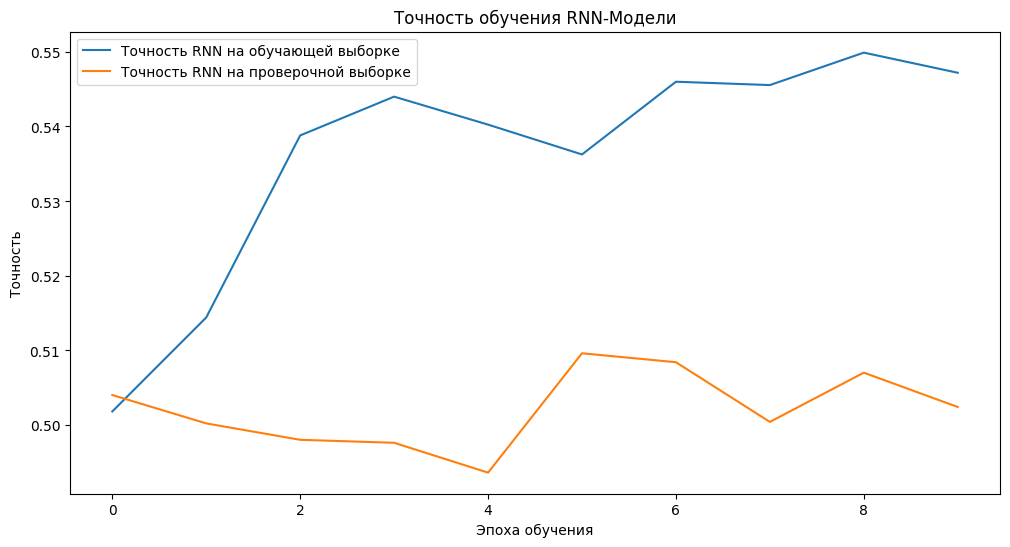

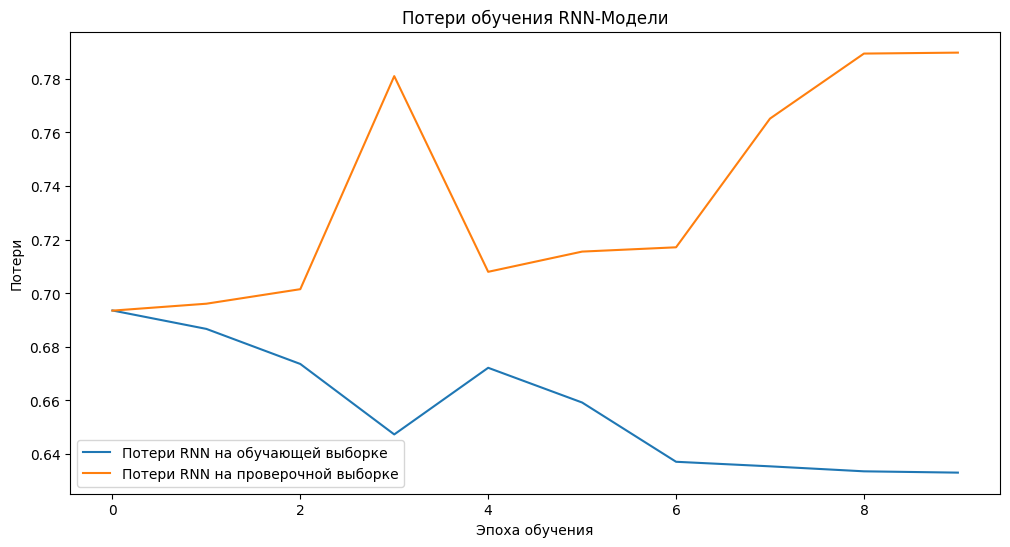

In [109]:
# Визуализация точности
plt.figure(figsize=(12, 6))
plt.plot(history_rnn.history['accuracy'], label='Точность RNN на обучающей выборке')
plt.plot(history_rnn.history['val_accuracy'], label='Точность RNN на проверочной выборке')
plt.xlabel('Эпоха обучения')
plt.ylabel('Точность')
plt.title('Точность обучения RNN-Модели')
plt.legend()
plt.show()

# Визуализация потерь
plt.figure(figsize=(12, 6))
plt.plot(history_rnn.history['loss'], label='Потери RNN на обучающей выборке')
plt.plot(history_rnn.history['val_loss'], label='Потери RNN на проверочной выборке')
plt.xlabel('Эпоха обучения')
plt.ylabel('Потери')
plt.title('Потери обучения RNN-Модели')
plt.legend()
plt.show()

Шаг 10: Оценка RNN-Модели на Тестовых Данных

In [110]:
# Оценка модели
test_loss_rnn, test_acc_rnn = model_rnn.evaluate(x_test_padded, y_test)
print(f'\nТочность RNN модели на тестовых данных: {test_acc_rnn:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.4928 - loss: 0.7851

Точность RNN модели на тестовых данных: 0.4996


In [ ]:
plot_training_history_and_evaluate(model_rnn, history_rnn, x_test_padded, y_test)

Шаг 11: Построение Модели с использованием LSTM

In [114]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_review_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='Nadam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

history_lstm = model_lstm.fit(
    x_train_padded, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.5030 - loss: 0.6933 - val_accuracy: 0.4938 - val_loss: 0.6928
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.5044 - loss: 0.6911 - val_accuracy: 0.5066 - val_loss: 0.6911
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.5138 - loss: 0.6836 - val_accuracy: 0.5202 - val_loss: 0.6871
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5325 - loss: 0.6723 - val_accuracy: 0.5142 - val_loss: 0.6832
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.5350 - loss: 0.6590 - val_accuracy: 0.5256 - val_loss: 0.6834
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5383 - loss: 0.6488 - val_accuracy: 0.5240 - val_loss: 0.6930
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5485 - loss: 0.6460 - val_accuracy: 0.5170 - val_loss: 0.6957
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5360 - loss: 0.6382 - val_accuracy: 0.5276 - val_loss:

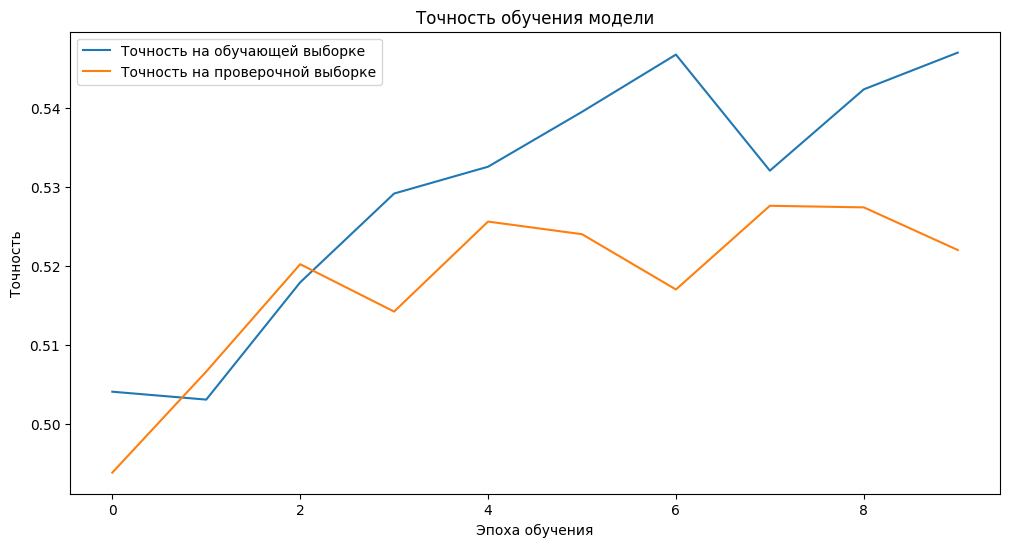

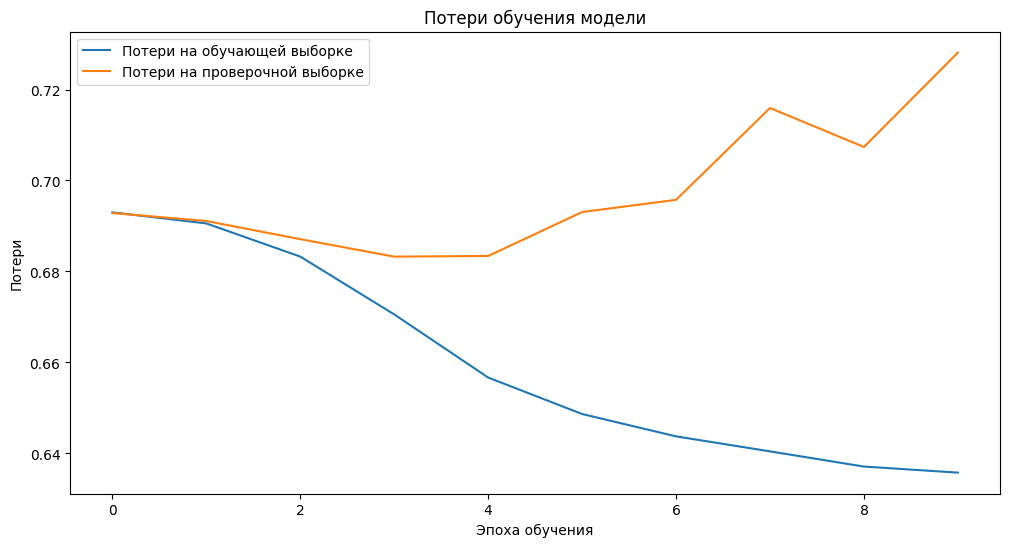

782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5273 - loss: 0.7163

Точность модели на тестовых данных: 0.5179


In [117]:
plot_training_history_and_evaluate(model_lstm, history_lstm, x_test_padded, y_test)

In [ ]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_review_len),
    GRU(64),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_gru = model_gru.fit(
    x_train_padded, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/10


/Users/zeto/.pyenv/versions/3.11.0/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.4995 - loss: 0.6932 - val_accuracy: 0.5054 - val_loss: 0.6925
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.5074 - loss: 0.6904 - val_accuracy: 0.5114 - val_loss: 0.7083
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5258 - loss: 0.6881 - val_accuracy: 0.5038 - val_loss: 0.6917
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5260 - loss: 0.6737 - val_accuracy: 0.5168 - val_loss: 0.7088
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5382 - loss: 0.6630 - val_accuracy: 0.5220 - val_loss: 0.7010
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5449 - loss: 0.6526 - val_accuracy: 0.5214 - val_loss: 0.6981
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5516 - loss: 0.6472 - val_accuracy: 0.5086 - val_loss: 0.7448
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5358 - loss: 0.6501 - val_accuracy: 0.5092 - val_loss: 0.7330
Epo

In [ ]:
plot_training_history_and_evaluate(model_gru, history_gru, x_test_padded, y_test)